In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['mathtext.fontset'] = 'cm'

In [6]:
VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing
import MulensModel as mm

class MyBinaryLens(mm.BinaryLensPointSourceWM95Magnification):
    """Custom BinaryLens class potentially for modifications or extensions."""
    def __init__(self, q, s):
        # Initialize the parent MulensModel.BinaryLens
        # Calculates mass fractions m1, m2 from q

        self.s1 = s

        parameters = {'q': q, 's': s, 't_0': 0, 't_E': 1, 'u_0': 0.006, 'alpha': 0}
        model_params = mm.ModelParameters(parameters=parameters)

        traj = mm.Trajectory(times=0, parameters=model_params)

        super().__init__(trajectory=traj)

    def get_n_images(self, x, y, shift):
        """
        Calculates the positions of images for a source at position (x, y).
        Relies on the _verify_polynomial_roots method from the parent class.
        """
        # Shift accounts for the coordinate system center (usually barycenter)
        # The length of the list of roots corresponds to the number of images
        self._get_1_magnification(x + shift[0], y + shift[1], separation=self.s1)

        return self._verify_polynomial_roots()

In [7]:
s1s = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# 1, 1/0.9, 1/0.8, 1/0.7, 1/0.6, 1/0.5, 1/0.4, 1/0.3, 1/0.2
alpha1 = 0
q1s = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3])

print(f'{len(s1s) * len(q1s)} binary lens configurations will be calculated.')

56 binary lens configurations will be calculated.


In [169]:
s1_str = '1/0.2'
s1 = eval(s1_str)

q1 = 1e-3

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

other_offset = np.array([0, 0])
print(f'Other offset: {other_offset}')

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1 + other_offset

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1 - other_offset)

num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

diff_y_plus = 1.0000
diff_y_minus = -0.9990
diff_thickness = diff_y_plus + diff_y_minus

print(f'Angular width: {ang_width}, Thickness: {diff_thickness}')
print(f'y_plus: {diff_y_plus}, y_minus: {diff_y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 4 * ang_width,
    'thickness': diff_thickness,
    'y_plus': diff_y_plus,
    'y_minus': diff_y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0.00019212 0.        ]
Other offset: [0 0]
Center of mass: [0.004995 0.      ]
Angular width: 0.0004815376930761557, Thickness: 0.0010000000000000009
y_plus: 1.0, y_minus: -0.999
Number of rays in r: 8141508, Number of rays in theta: 2035377
Total number of rays: 1.657e+13


100%|██████████| 500/500 [00:03<00:00, 140.18it/s]


---------------------
Total time: 3.578 seconds


/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:685: RuntimeWarning: divide by zero encountered in log10
  self.magnifications_log = np.log10(self.magnifications)


In [170]:
model = MyBinaryLens(q=q1, s=s1)

image_pos = model.get_n_images(x=ang_width/2, y=ang_width/2, shift=[0, 0])

print(image_pos)

[-5.99585567e+00-4.70430706e-02j -3.99919647e+00+4.89411909e-02j
  2.08334380e-04-1.04610283e-08j]


In [171]:
r1 = diff_y_plus
r2 = -diff_y_minus

small_num_theta = 100

rs_old = np.array([r1, r2]).reshape(-1, 1)
rs_new = abs(image_pos).reshape(-1, 1)
print(rs_new)

thetas = np.linspace(0, 2*np.pi - (2*np.pi / small_num_theta), small_num_theta).reshape(1, -1)

X_old = np.dot(rs_old, np.cos(thetas))
Y_old = np.dot(rs_old, np.sin(thetas))

X_new = np.dot(rs_new, np.cos(thetas))
Y_new = np.dot(rs_new, np.sin(thetas))

(xs_old, ys_old) = sim.calc_source_pixels(X_old, Y_old)
(xs_new, ys_new) = sim.calc_source_pixels(X_new, Y_new)

[[5.99604022e+00]
 [3.99949592e+00]
 [2.08334381e-04]]


Plotting magnification map: 0.057 seconds
Cusp point 0: [-5.32266878e-05  0.00000000e+00]
Cusp point 1: [0.00012038 0.        ]
Cusp point 2: [0.00000000e+00 8.22172932e-05]
Cusp point 3: [ 0.00000000e+00 -8.22172932e-05]
(-5.995855673820322-0.0470430705964966j)
(-3.999196468315273+0.048941190858120175j)
(0.00020833438029044233-1.046102827773803e-08j)


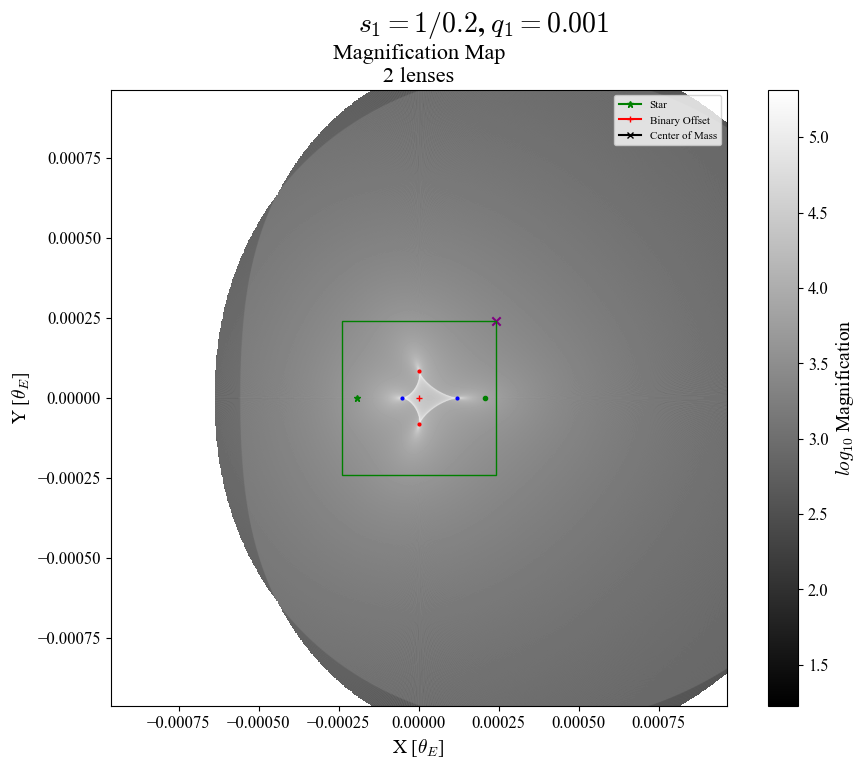

In [172]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(f'Cusp point {i}: {points}')
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='g', marker='*', markersize=5, label='Star')

sim.ax_c.plot(*(delta1 - delta1 - other_offset), color='r', marker='+', markersize=5, label='Binary Offset')
sim.ax_c.plot(*(center_of_mass - delta1 - other_offset), color='k', marker='x', markersize=5, label='Center of Mass')

# sim.ax_c.scatter(X_old[0], Y_old[0], color='blue', marker='x', label='Single Lens Image 1')
# sim.ax_c.scatter(X_old[1], Y_old[1], color='green', marker='x', label='Single Lens Image 2')

# sim.ax_c.scatter(xs_old[0], ys_old[0], color='blue', marker='o', label='Single Lens Source 1')
# sim.ax_c.scatter(xs_old[1], ys_old[1], color='green', marker='o', label='Single Lens Source 2')

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='red', linestyle='--', linewidth=1)

sim.ax_c.set_aspect('equal')

new_ang_width = 2 * ang_width

sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
sim.ax_c.set_ylim(-new_ang_width, new_ang_width)

for pos in image_pos:
    print(pos)
    sim.ax_c.scatter(pos.real, pos.imag, color='green', marker='.')

sim.ax_c.scatter(ang_width / 2, ang_width / 2, color='purple', marker='x')

sim.ax_c.add_patch(map_patch)
sim.ax_c.add_patch(ring)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')
sim.ax_c.legend(loc='upper right')

plt.show()

#### Seeing differences between single lens source and image positions and binary lens source and image positions

In [25]:
# Defining source position
x = 1.1 * ang_width / np.sqrt(2)
y = 0

In [26]:
# Finding single lens image position
u = np.sqrt(x**2 + y**2)
y_plus = 0.5 * (u + np.sqrt(u**2 + 4))
y_minus = 0.5 * (u - np.sqrt(u**2 + 4))

single_image_positions = np.array([
    [y_plus, 0],
    [-y_minus, 0],
    [-y_plus, 0],
    [y_minus, 0],
    [0, y_plus],
    [0, -y_minus],
    [0, -y_plus],
    [0, y_minus]
]).reshape(-1, 2)
print(single_image_positions)

single_source_positions = []
# Finding single lens source position
for pos in single_image_positions:
    z = pos[0] + pos[1]*1.0j

    zbar = np.conj(z)
    
    zm = sim.lens_att[:, 0] + sim.lens_att[:, 1]*1j
    epsilon = sim.lens_att[:, sim.mass_index] / sim.total_M
    zmbar = np.conj(zm)

    sums = np.zeros_like(z, dtype=np.complex128)
    for i in range(sim.L):
        sums += epsilon[i] / (zbar - zmbar[i]) # [theta_e]

    zeta = z - sums

    single_source_positions.append([zeta.real, zeta.imag])

single_source_positions = np.array(single_source_positions).reshape(-1, 2)
print(single_source_positions)

[[ 1.00018729  0.        ]
 [ 0.99981274  0.        ]
 [-1.00018729  0.        ]
 [-0.99981274  0.        ]
 [ 0.          1.00018729]
 [ 0.          0.99981274]
 [ 0.         -1.00018729]
 [ 0.         -0.99981274]]
[[ 1.81495123e-03  0.00000000e+00]
 [ 1.06634890e-03  0.00000000e+00]
 [-1.01497341e-03  0.00000000e+00]
 [-2.66096533e-04  0.00000000e+00]
 [ 2.67847719e-07  1.33496661e-03]
 [ 1.29614050e-07  5.86257258e-04]
 [ 2.67847719e-07 -1.33496661e-03]
 [ 1.29614050e-07 -5.86257258e-04]]


In [27]:
# Finding binary lens image position
model = MyBinaryLens(q=q1, s=s1)
image_pos = model.get_n_images(x=x, y=y, shift=[0, 0])

binary_image_positions = []
for pos in image_pos:
    binary_image_positions.append([pos.real, pos.imag])

binary_image_positions = np.array(binary_image_positions).reshape(-1, 2)
print(binary_image_positions)

binary_source_positions = []
# Finding binary lens source position
for pos in binary_image_positions:
    z = pos[0] + pos[1]*1.0j

    zbar = np.conj(z)
    
    zm = sim.lens_att[:, 0] + sim.lens_att[:, 1]*1j
    epsilon = sim.lens_att[:, sim.mass_index] / sim.total_M
    zmbar = np.conj(zm)

    sums = np.zeros_like(z, dtype=np.complex128)
    for i in range(sim.L):
        sums += epsilon[i] / (zbar - zmbar[i]) # [theta_e]

    zeta = z - sums

    binary_source_positions.append([zeta.real, zeta.imag])

binary_source_positions = np.array(binary_source_positions).reshape(-1, 2)
print(binary_source_positions)

[[-5.99690228e+00  0.00000000e+00]
 [-3.99793651e+00  0.00000000e+00]
 [ 2.08340193e-04  0.00000000e+00]]
[[   -5.83021992     0.        ]
 [   -3.74793432     0.        ]
 [-2494.65961312     0.        ]]


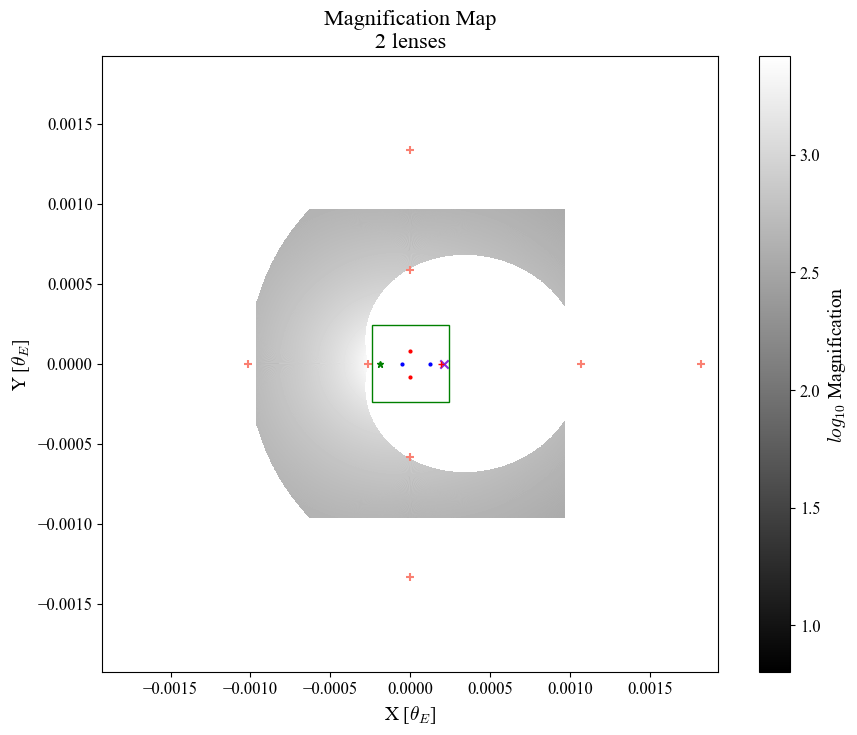

In [28]:
fig, ax = sim.plot_mags_map()

for i, points in enumerate(cusp_points[0]):
    if i < 2:
        ax.plot(*(points), 'bo', markersize=2)
    else:
        ax.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='red', linestyle='--', linewidth=1)

ax.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='g', marker='*', markersize=5, label='Star')

ax.plot(*(delta1), color='r', marker='+', markersize=5, label='Binary Offset')
ax.plot(*(center_of_mass), color='k', marker='x', markersize=5, label='Center of Mass')

# Plotting single lens source and image positions
ax.scatter(single_image_positions[:, 0], single_image_positions[:, 1], color='salmon', marker='x', label='Single Lens Image')
ax.scatter(single_source_positions[:, 0], single_source_positions[:, 1], color='salmon', marker='+', label='Single Lens Source')

# Plotting binary lens source and image positions
ax.scatter(binary_image_positions[:, 0], binary_image_positions[:, 1], color='blueviolet', marker='x', label='Binary Lens Image')
ax.scatter(binary_source_positions[:, 0], binary_source_positions[:, 1], color='blueviolet', marker='+', label='Binary Lens Source')

new_ang_width = 4 * ang_width

ax.set_xlim(-new_ang_width, new_ang_width)
ax.set_ylim(-new_ang_width, new_ang_width)

ax.add_patch(map_patch)
ax.add_patch(ring)
ax.set_aspect('equal')

plt.show()

#### Plotting critical curves and caustics with VBMicrolensing

[0, 0, 1, 5.0, 0, 0.5]
[0.004995 0.      ]
[0.00019212 0.        ]


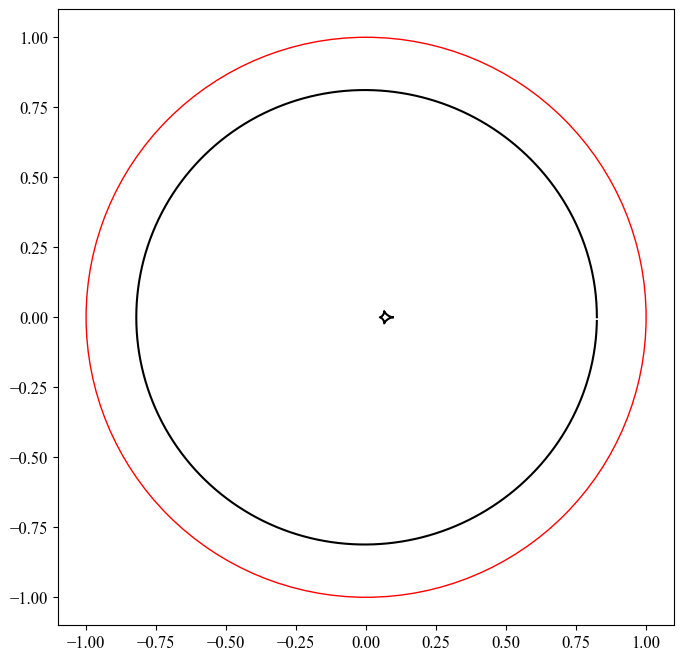

In [189]:
import VBMicrolensing
from matplotlib import pyplot as plt

VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing

parameters = [0, 0, 1,
                1/0.2, 0, 0.5]
print(parameters)

VBM.SetLensGeometry(parameters)
caustics = VBM.Multicaustics()
criticalcurves = VBM.Multicriticalcurves()

single_parameters = [0, 0, 1]
VBM.SetLensGeometry(single_parameters)
single_criticalcurves = VBM.Multicriticalcurves()

print(center_of_mass)
print(delta1)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

for cau in caustics:
        ax.plot(cau[0] - delta1[0], cau[1] - delta1[1], 'k')


ax.plot(criticalcurves[0][0] - delta1[0], criticalcurves[0][1] - delta1[1], 'k')

# for single_crit in single_criticalcurves:
#         ax.plot(single_crit[0] - delta1[0], single_crit[1] - delta1[1], 'r')

circle = plt.Circle((0, 0), 1, color='r', fill=False)
ax.add_artist(circle)

ax.set_aspect('equal')

limit = 1.1

ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])

plt.show()

In [185]:
print(np.shape(single_criticalcurves[0]))
print(np.shape(criticalcurves[0]))

(2, 400)
(2, 400)


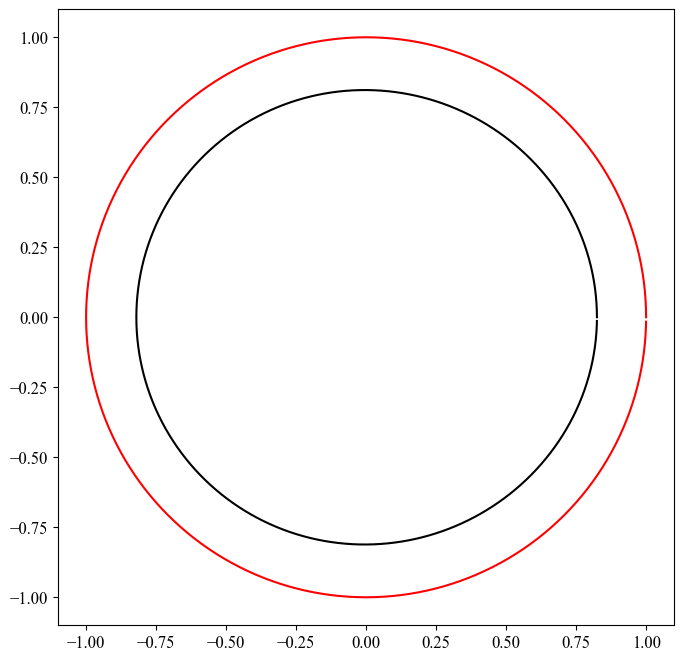

In [186]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

einstein_ring = np.array(single_criticalcurves[0])
distorted_einstein_ring = np.array(criticalcurves[0])

ax.plot(einstein_ring[0] - delta1[0], einstein_ring[1] - delta1[1], 'r')
ax.plot(distorted_einstein_ring[0] - delta1[0], distorted_einstein_ring[1] - delta1[1], 'k')

ax.set_aspect('equal')

plt.show()

0.8165066978773047


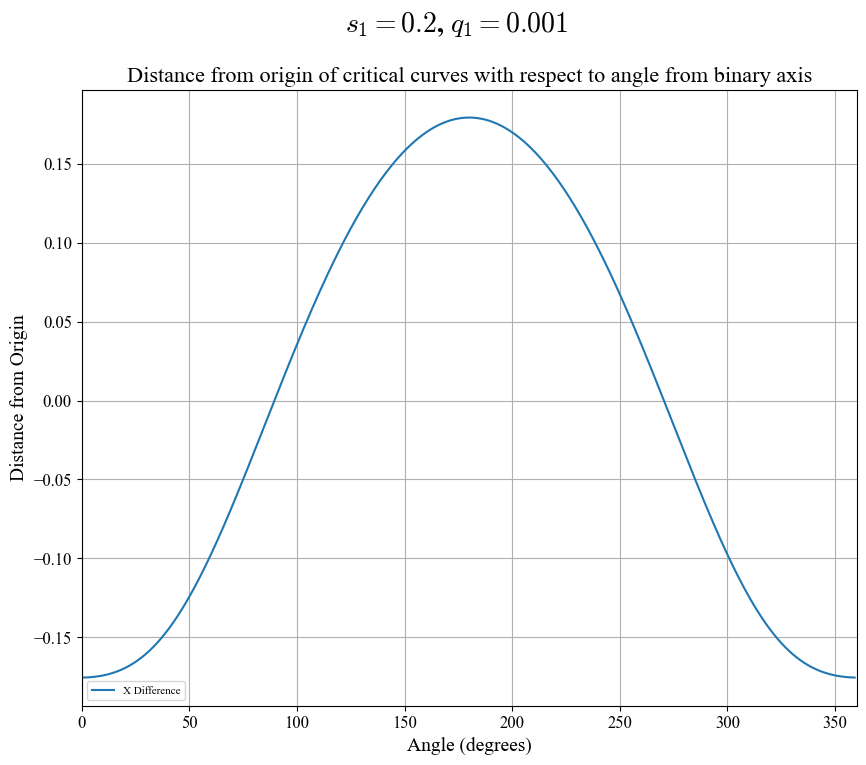

In [187]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

angles = np.linspace(0, 2*np.pi - (2*np.pi)/len(distorted_einstein_ring[0]), len(distorted_einstein_ring[0])) * 180/np.pi

distances = np.sqrt(einstein_ring[0]**2 + einstein_ring[1]**2)
distorted_distances = np.sqrt(distorted_einstein_ring[0]**2 + distorted_einstein_ring[1]**2)

print(np.mean(distorted_distances))

fig.suptitle(f'$s_1 = {0.2}$, $q_1 = {q1}$')

ax.set_title('Distance from origin of critical curves with respect to angle from binary axis')
# ax.plot(angles, distances, label='Single Lens Critical Curve (Einstein Ring)')
# ax.plot(angles, distorted_distances, label='Binary Lens Critical Curve')
ax.plot(angles, distorted_einstein_ring[0] - einstein_ring[0], label='X Difference')

ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Distance from Origin')

ax.set_xlim([0, 360])
# ax.set_ylim([0.9992, 1.00010])

ax.grid(True)

plt.legend(loc='lower left')
plt.show()

In [182]:
np.sqrt(1 - 1e-3)

np.float64(0.999499874937461)

In [91]:
def sample_circle_points(num_points):
    angles = np.linspace(0, 2*np.pi, num_points, endpoint=False)
    x = np.cos(angles)
    y = np.sin(angles)
    return x, y

In [19]:
critical_curves = []
single_critical_curves = []
angles = []

s_vector = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1/0.9, 1, 1/0.8, 1/0.7, 1/0.6, 1/0.5, 1/0.4, 1/0.3, 1/0.2]

for s in s_vector:
    parameters = [0, 0, 1,
                s, 0, 1e-3]
    
    VBM.SetLensGeometry(parameters)
    caustics = VBM.Multicaustics()
    critical_curves.append(VBM.Multicriticalcurves())

    single_critical_curves.append(sample_circle_points(len(critical_curves[-1][0][0])))

    angles.append(np.linspace(0, 2*np.pi, len(critical_curves[-1][0][0]), endpoint=False) * 180/np.pi)

critical_curves = np.array(critical_curves, dtype=object)

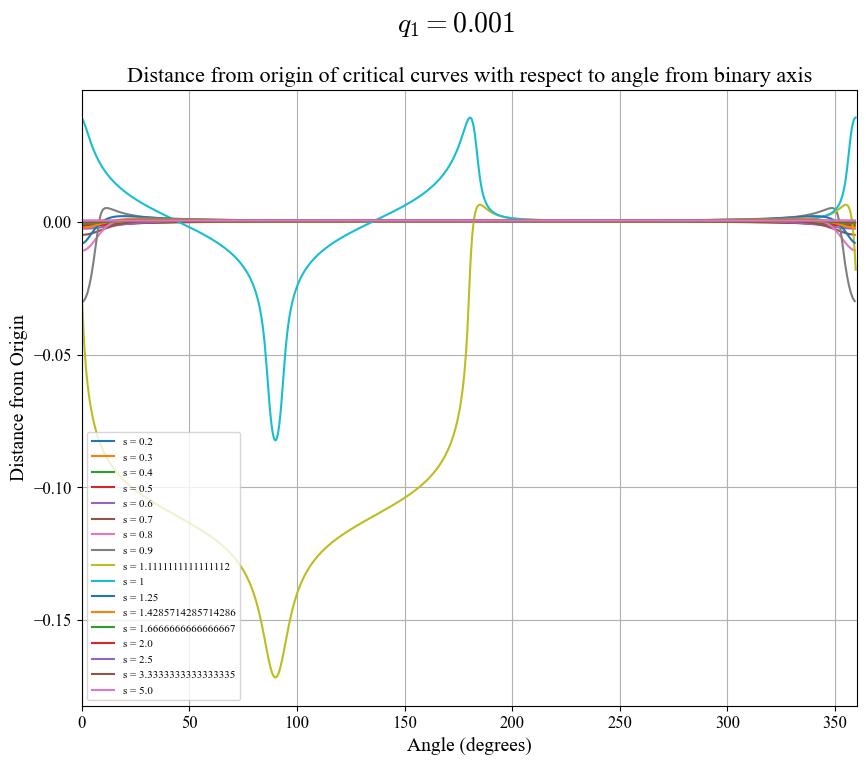

In [20]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

# distances = np.sqrt(einstein_ring[0]**2 + einstein_ring[1]**2)
distorted_distances = []

for i, curve in enumerate(critical_curves):
    distorted_distances.append(np.sqrt(np.array(curve[0][0])**2 + np.array(curve[0][1])**2))
    ones = np.ones(len(distorted_distances[-1]))
    
    ax.plot(angles[i], ones - distorted_distances[-1], label=f's = {s_vector[i]}')

# distorted_distances = np.sqrt(distorted_einstein_ring[0]**2 + distorted_einstein_ring[1]**2)

fig.suptitle(f'$q_1 = {q1}$')

ax.set_title('Distance from origin of critical curves with respect to angle from binary axis')
# ax.plot(angles, distances, label='Single Lens Critical Curve (Einstein Ring)')
# ax.plot(angles, distorted_distances, label='Binary Lens Critical Curve')

ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Distance from Origin')

ax.set_xlim([0, 360])
# ax.set_ylim([0.9992, 1.00010])

ax.grid(True)

plt.legend(loc='lower left')
plt.show()

For s > 1+3q, find the offset of the central critical curve (mean of the x values) and plot the offset vs s (should be something like q/s) and then use that as the center of the annulus

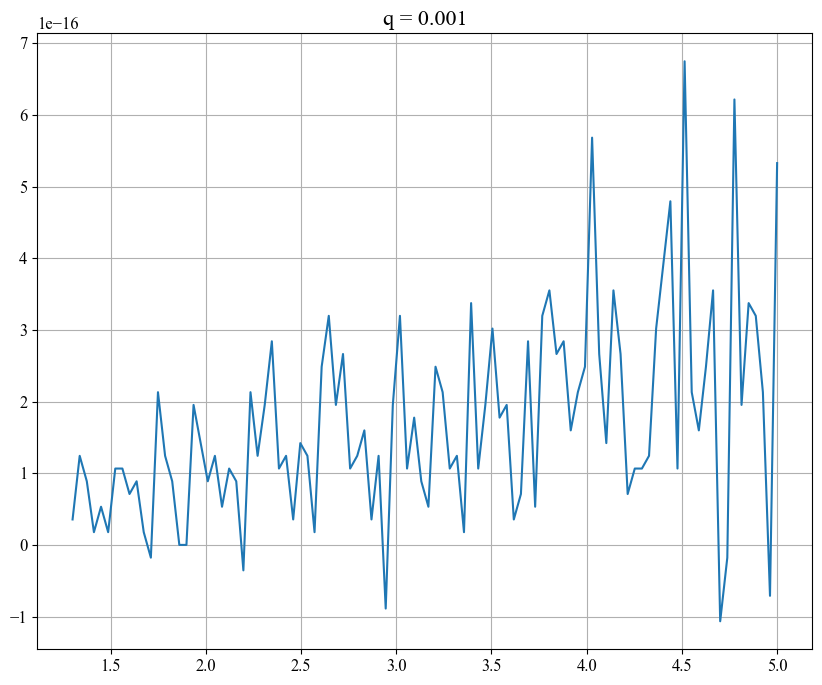

In [296]:
q = 1e-3
# ss = np.linspace(1.3, 1.4, 2)
ss = np.linspace(1.3, 5, 100)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

offsets = []

color_cycle = plt.cm.viridis(np.linspace(0, 1, len(ss)))

for i, s in enumerate(ss):
    # VBM.SetLensGeometry([0, 0, 1,
    #                      s, 0, q])
    
    # criticalcurves = VBM.Multicriticalcurves()
    criticalcurves = VBM.Criticalcurves(s, q)
    center_mass = q * s / (1 + q)
    delta = q / ((1 + q) * (s + 1/s))

    main_curve = np.array(criticalcurves[-1])

    # angles = np.linspace(0, 180, len(main_curve[0]), endpoint=False)
    # ax.plot(angles, main_curve[0], label=f's = {s:.2f}')

    offsets.append(np.mean(main_curve[0] + center_mass))

    # for criticalcurve in criticalcurves:
    #     ax.plot(criticalcurve[0], criticalcurve[1], label=f's = {s:.2f}', color=color_cycle[i])
    # ax.plot(main_curve[0] + center_mass, main_curve[1], label=f's = {s:.2f}')

# ax.set_aspect('equal')
ax.plot(ss, offsets)

# ax.legend()
# ax.set_xlabel('Angle from binary axis')
# ax.set_ylabel('X coordinate of central critical curve')
ax.set_title(f'q = {q}')
ax.grid(True)

plt.show()

In [8]:
s1_str = '1/2'
s1 = eval(s1_str)

q1 = 1e-3

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

other_offset = np.array([0, 0])
print(f'Other offset: {other_offset}')

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1 + other_offset

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1 - other_offset)

num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

diff_y_plus = y_plus
diff_y_minus = y_minus
diff_thickness = diff_y_plus + diff_y_minus

print(f'Angular width: {ang_width}, Thickness: {diff_thickness}')
print(f'y_plus: {diff_y_plus}, y_minus: {diff_y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 4 * ang_width,
    'thickness': diff_thickness,
    'y_plus': diff_y_plus,
    'y_minus': diff_y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0.0003996 0.       ]
Other offset: [0 0]
Center of mass: [0.0004995 0.       ]
Angular width: 0.006401598401598402, Thickness: 0.00497927500422346
y_plus: 1.0024927366447554, y_minus: -0.9975134616405319
Number of rays in r: 8141476, Number of rays in theta: 2035369
Total number of rays: 1.657e+13


100%|██████████| 500/500 [00:03<00:00, 143.21it/s]

---------------------
Total time: 3.528 seconds



/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:685: RuntimeWarning: divide by zero encountered in log10
  self.magnifications_log = np.log10(self.magnifications)


Plotting magnification map: 0.051 seconds
Cusp point 0: [-0.00017738  0.        ]
Cusp point 1: [0.0016004 0.       ]
Cusp point 2: [0.         0.00060961]
Cusp point 3: [ 0.         -0.00060961]


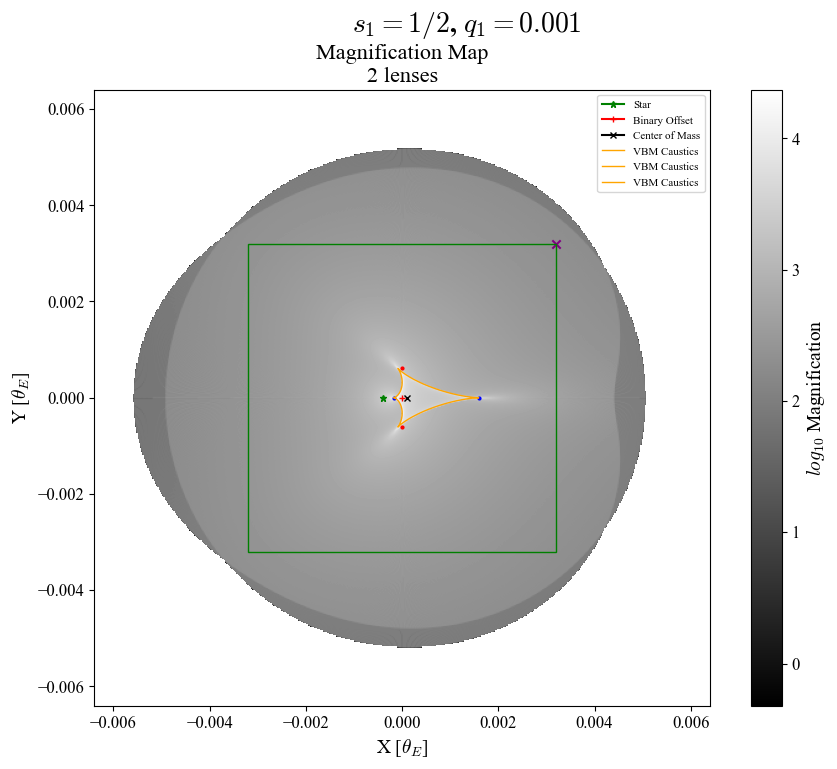

In [10]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(f'Cusp point {i}: {points}')
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='g', marker='*', markersize=5, label='Star')

sim.ax_c.plot(*(delta1 - delta1 - other_offset), color='r', marker='+', markersize=5, label='Binary Offset')
sim.ax_c.plot(*(center_of_mass - delta1 - other_offset), color='k', marker='x', markersize=5, label='Center of Mass')

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='red', linestyle='--', linewidth=1)

sim.ax_c.set_aspect('equal')

new_ang_width = 1 * ang_width

sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
sim.ax_c.set_ylim(-new_ang_width, new_ang_width)


sim.ax_c.scatter(ang_width / 2, ang_width / 2, color='purple', marker='x')

# VBM.SetLensGeometry(sim.lens_att.flatten().tolist())
caustics = VBM.Caustics(s1, q1)
# print(caustics)

for caustic in caustics:
    sim.ax_c.plot(caustic[0] + center_of_mass[0] - delta1[0], caustic[1] + center_of_mass[1] - delta1[1], 'orange', linewidth=1, label='VBM Caustics')

sim.ax_c.add_patch(map_patch)
sim.ax_c.add_patch(ring)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')
sim.ax_c.legend(loc='upper right')

plt.show()

In [11]:
s1_str = '2'
s1 = eval(s1_str)

q1 = 1e-3

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

other_offset = np.array([0, 0])
print(f'Other offset: {other_offset}')

# Calculating center of mass of lenses
center_of_mass = np.average(binary_lens_attributes[:, :2], axis=0, weights=binary_lens_attributes[:, 2])
print(f'Center of mass: {center_of_mass}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1 + other_offset

pixels = 2000
delta = 0.001

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes, cm_offset='auto', cm_translation=delta1 - other_offset)

num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

diff_y_plus = y_plus
diff_y_minus = y_minus
diff_thickness = diff_y_plus + diff_y_minus

print(f'Angular width: {ang_width}, Thickness: {diff_thickness}')
print(f'y_plus: {diff_y_plus}, y_minus: {diff_y_minus}')
print(f'Number of rays in r: {num_r}, Number of rays in theta: {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

binary_lens_parameters = {
    'pixels': 1000,
    'ang_width': 4 * ang_width,
    'thickness': diff_thickness,
    'y_plus': diff_y_plus,
    'y_minus': diff_y_minus,
    'lens_att': binary_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=binary_lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto')

Binary offset: [0.0003996 0.       ]
Other offset: [0 0]
Center of mass: [0.001998 0.      ]
Angular width: 0.006401598401598402, Thickness: 0.00497927500422346
y_plus: 1.0024927366447554, y_minus: -0.9975134616405319
Number of rays in r: 8141476, Number of rays in theta: 2035369
Total number of rays: 1.657e+13


100%|██████████| 500/500 [00:03<00:00, 130.34it/s]

---------------------
Total time: 3.846 seconds



/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:685: RuntimeWarning: divide by zero encountered in log10
  self.magnifications_log = np.log10(self.magnifications)


Plotting magnification map: 0.018 seconds
Cusp point 0: [-0.00017738  0.        ]
Cusp point 1: [0.0016004 0.       ]
Cusp point 2: [0.         0.00060961]
Cusp point 3: [ 0.         -0.00060961]


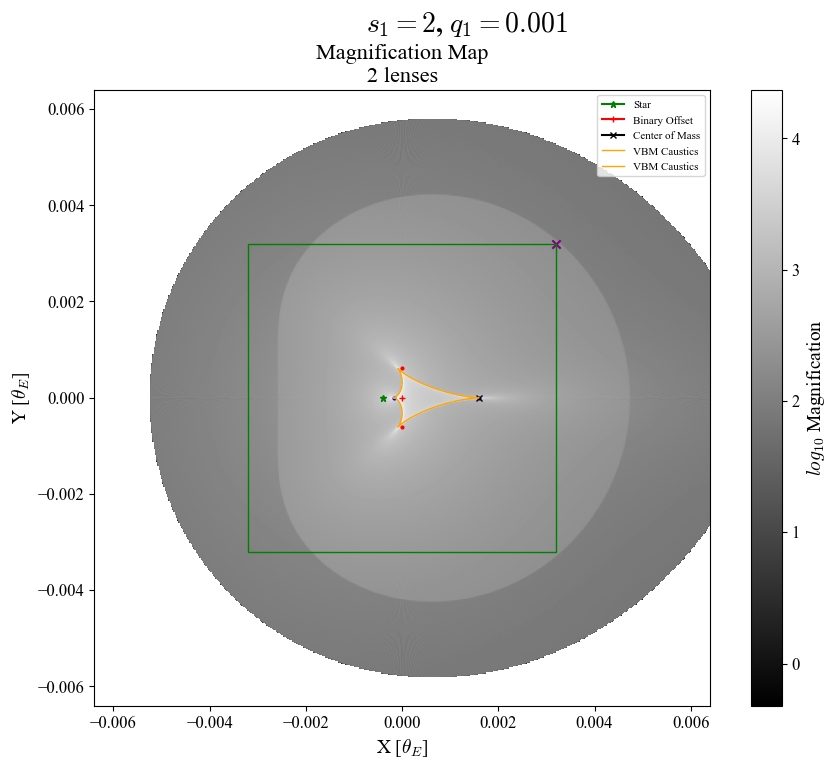

In [12]:
sim.plot()

for i, points in enumerate(cusp_points[0]):
    print(f'Cusp point {i}: {points}')
    if i < 2:
        sim.ax_c.plot(*(points), 'bo', markersize=2)
    else:
        sim.ax_c.plot(*(points), 'ro', markersize=2)

map_patch = patches.Rectangle(
    xy=(-ang_width/2, -ang_width/2),
    width=ang_width,
    height=ang_width,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
)

sim.ax_c.plot(sim.lens_att[0, 0], sim.lens_att[0, 1], color='g', marker='*', markersize=5, label='Star')

sim.ax_c.plot(*(delta1 - delta1 - other_offset), color='r', marker='+', markersize=5, label='Binary Offset')
sim.ax_c.plot(*(center_of_mass - delta1 - other_offset), color='k', marker='x', markersize=5, label='Center of Mass')

ring = patches.Circle((0, 0), 1, fill=False, edgecolor='red', linestyle='--', linewidth=1)

sim.ax_c.set_aspect('equal')

new_ang_width = 1 * ang_width

sim.ax_c.set_xlim(-new_ang_width, new_ang_width)
sim.ax_c.set_ylim(-new_ang_width, new_ang_width)

sim.ax_c.scatter(ang_width / 2, ang_width / 2, color='purple', marker='x')

# VBM.SetLensGeometry(sim.lens_att.flatten().tolist())
caustics = VBM.Caustics(s1, q1)
# print(caustics)

for caustic in caustics:
    sim.ax_c.plot(caustic[0] + center_of_mass[0] - delta1[0], caustic[1] + center_of_mass[1] - delta1[1], 'orange', linewidth=1, label='VBM Caustics')

sim.ax_c.add_patch(map_patch)
sim.ax_c.add_patch(ring)
sim.fig_c.suptitle(f'$s_1 = {s1_str}$, $q_1 = {q1}$')
sim.ax_c.legend(loc='upper right')

plt.show()

In [351]:
s1s = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1/0.8, 1/0.7, 1/0.6, 1/0.5, 1/0.4, 1/0.3, 1/0.2])
q1s = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3])

mean_distance = []

for s in s1s:
    constant_s = []

    for q in q1s:
        VBM.SetLensGeometry([0, 0, 1,
                             s, 0, q])
        
        critical_curve = VBM.Multicriticalcurves()
        main_curve = np.array(critical_curve[0])

        distances = np.sqrt(main_curve[0]**2 + main_curve[1]**2)

        constant_s.append(np.mean(distances))

    mean_distance.append(constant_s)

mean_distance = np.array(mean_distance)

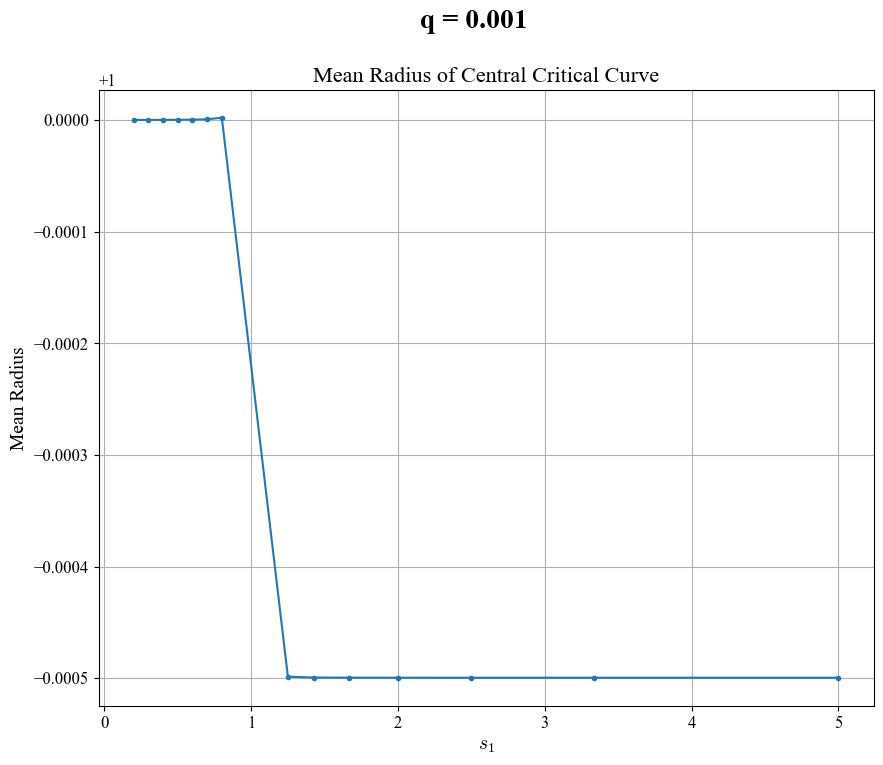

In [357]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

q_ind = -1

fig.suptitle(f'q = {q1s[q_ind]}')
ax.set_title('Mean Radius of Central Critical Curve')

ax.plot(s1s, mean_distance[:, q_ind], marker='.')

ax.set_xlabel('$s_1$')
ax.set_ylabel('Mean Radius')
ax.grid(True)

plt.show()

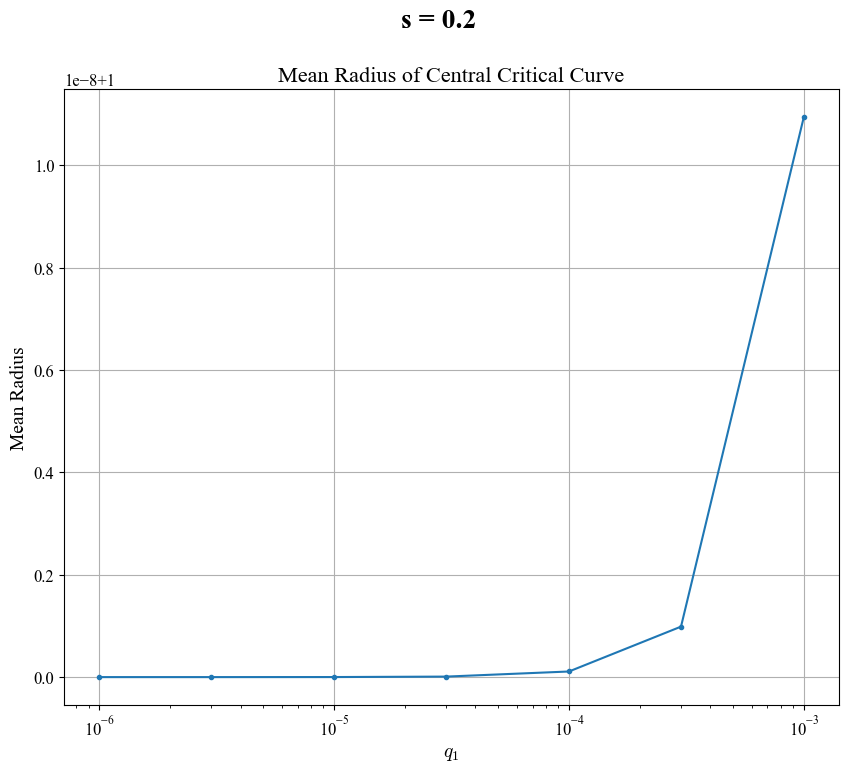

In [358]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

s_ind = 0

fig.suptitle(f's = {s1s[s_ind]}')
ax.set_title('Mean Radius of Central Critical Curve')

ax.semilogx(q1s, mean_distance[s_ind, :], marker='.')

ax.set_xlabel('$q_1$')
ax.set_ylabel('Mean Radius')
ax.grid(True)

plt.show()